# 02: Annotation Accuracy

*How accurate and internally consistent are the KG's entity annotations and relation assignments?*

This notebook evaluates **annotation accuracy** across all KGs listed in `config.yaml`, examining whether nodes resolve to valid ontology entries and whether edges are typed and logically consistent.

| Metric | Definition | Quantification | Scoring |
|--------|-----------|----------------|---------|
| **Entity validity** | Fraction of entity identifiers that conform to canonical namespace patterns for their type | Prefix/regex validation against known ID schemes per entity type; valid IDs / total IDs per shared canonical type; macro-averaged across shared types | Direct proportion (0–1); no transformation |
| **Relational consistency** | Fraction of edges whose head–relation–tail type triple conforms to the KG's declared schema | Edges conforming to schema / total edges; schema defined per KG as the set of allowed (head type, relation, tail type) triples | Direct proportion (0–1); no transformation |
| **Dimension score** | — | — | Equal-weighted mean of entity validity and relational consistency |

> **Relation exclusivity** (whether relation types are semantically exclusive) is diagnostic only and does not enter the dimension score. KGs that do not define semantically exclusive relation pairs (e.g. DRKG, which lacks indication/contraindication edges) would receive a vacuous perfect score, rewarding schema design choices rather than curation quality.

> **API spot-checks.** A small random sample per entity type is validated against live endpoints (DrugBank, NCBI, EBI OLS4, QuickGO, Reactome). These are informational only and do not enter the dimension score.

**Inputs:** `config.yaml` · KG edge/node files (via `load_kg`) · `data/validation_cache.json`

**Outputs:** `results/figures/02_id_validation.{pdf,png}` · `results/checkpoints/02_semantic_validity.pkl`

**Dependencies:** `src/loading.py` · `src/plotting.py`

## Set-up

KGs are loaded from `config.yaml`. Namespace validation is computed over all nodes without network access. API spot-checks sample up to `N_API_SAMPLES` nodes per entity type per KG and hit live endpoints (DrugBank, NCBI E-utilities, EBI OLS4, QuickGO, Reactome); results are cached to `data/validation_cache.json` to avoid redundant HTTP requests on re-runs.

**Reproducibility note.** All API responses are cached deterministically. Re-running this notebook will produce identical results as long as the cache file is present. To force re-validation, delete `data/validation_cache.json`.

In [1]:
# Imports
import sys, os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import Optional, Dict

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json as _json_mod
import pickle
import ssl
import time
import urllib.request, urllib.parse
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.colors as mcolors
from src.plotting import (setup_style, save_fig, TEXT_COLOR, TICK_COLOR, KG_PALETTE, HEATMAP_CMAP)
from src.loading import find_config, load_config, load_kg

setup_style()

In [2]:
# Config and paths
config = load_config(find_config(_root))
params = config['analysis_params']
BASE   = config['_base_dir']
FIGS   = BASE / 'results' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

In [3]:
# Load KGs
kgs = {}
for name in config['knowledge_graphs']:
    try:
        kg, nodes = load_kg(name, config)
        kgs[name] = {'kg': kg, 'nodes': nodes}
        print(f'{name:12s}: {len(kg):>12,} edges  {len(nodes):>8,} nodes  '
              f'{kg["relation"].nunique():>4} relation types')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND - skipped]')
    except Exception as e:
        print(f'{name:12s}: [ERROR: {e}]')

KG_NAMES  = list(kgs.keys())
LOADED    = [n for n in kgs if config['knowledge_graphs'].get(n, {}).get('relations')]
KG_COLORS = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}

primekg     :    8,100,498 edges   129,375 nodes    30 relation types
hetionet    :    2,250,197 edges    47,031 nodes    24 relation types
drkg        :    5,874,261 edges    97,238 nodes   107 relation types
openbilink  :    4,986,521 edges   185,929 nodes    28 relation types
biokg       :    2,067,998 edges   105,524 nodes    17 relation types


## 1. Entity Validity

Entity validity assesses whether nodes are correctly typed and uniquely indexed.

$$\text{Validation Rate}_t = \frac{|\{n \in \text{KG}_t : \text{id}(n) \text{ matches canonical pattern}\}|}{|\text{KG}_t|}$$

Each node's identifier is matched against canonical namespace prefixes for its entity type (e.g., `DB*` for DrugBank compounds, `GO:*` for Gene Ontology terms). The set of accepted patterns is defined in `VALID_PATTERNS` below. Entity types present in some KGs but lacking a gold-standard namespace definition (e.g., Pharmacologic Class, Side Effect) are marked **out of scope** and excluded from scoring.

### Namespace validation

Every node is checked for ID–type consistency: the node's identifier is matched against canonical prefixes for its entity type. The prefix patterns are broad enough to accommodate cross-references (e.g., `UMLS:`, `MESH:`) but specific enough to catch namespace leakage (e.g., DrugBank IDs appearing under Gene nodes).

- **Unrecognised types** are flagged with a warning — these may indicate a KG schema change.
- **Out-of-scope types** (e.g., Pharmacologic Class, Symptom, Taxonomic hierarchy) are skipped silently.
- **Validation rate < 95%** triggers an automatic prefix-frequency breakdown of failing IDs.

In [4]:
# HTTP cache + utilities
_vp           = params.get('validation', {})
N_SAMPLES     = _vp.get('n_samples', 100)    # namespace validation: nodes per type
N_API_SAMPLES = 10                            # API spot-check: smaller live-request budget
TIMEOUT       = _vp.get('api_timeout', 10)
SLEEP         = _vp.get('api_sleep', 0.5)

ctx = ssl.create_default_context()

_CACHE_PATH = BASE / 'data' / 'validation_cache.json'
_api_cache: dict = _json_mod.loads(_CACHE_PATH.read_text()) if _CACHE_PATH.exists() else {}

def _save_cache() -> None:
    _CACHE_PATH.write_text(_json_mod.dumps(_api_cache, indent=1))

def _get_json(url: str):
    if url in _api_cache:
        return _api_cache[url]
    try:
        resp   = urllib.request.urlopen(
            urllib.request.Request(url, headers={'Accept': 'application/json',
                                                 'User-Agent': 'BioKGSuite/1.0'}),
            timeout=TIMEOUT, context=ctx)
        result = _json_mod.loads(resp.read())
    except Exception:
        result = None
    _api_cache[url] = result
    _save_cache()
    return result

def _get_status(url: str):
    key = f'__status__{url}'
    if key in _api_cache:
        return _api_cache[key]
    try:
        status = urllib.request.urlopen(
            urllib.request.Request(url, headers={'User-Agent': 'BioKGSuite/1.0'}),
            timeout=TIMEOUT, context=ctx).status
    except urllib.error.HTTPError as e:
        status = e.code
    except Exception:
        status = None
    _api_cache[key] = status
    _save_cache()
    return status

In [5]:
# Validator functions

def validate_gene_protein(df: pd.DataFrame) -> int:
    ids, valid = df['node_id'].astype(str).tolist(), 0
    for i in range(0, len(ids), 200):
        batch = ids[i:i+200]
        data  = _get_json('https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi'
                          f'?db=gene&id={",".join(batch)}&retmode=json')
        if data and 'result' in data:
            valid += sum(1 for gid in batch
                         if data['result'].get(gid) and 'error' not in data['result'][gid])
        time.sleep(SLEEP * 3)
    return valid

def validate_go_term(df: pd.DataFrame, aspect: str) -> int:
    valid = 0
    for _, row in df.iterrows():
        raw   = str(row['node_id']).strip()
        go_id = raw if raw.upper().startswith('GO:') else (
                'GO:' + f'{int(raw):07d}' if raw.isdigit() else None)
        if go_id is None:
            continue
        data = _get_json('https://www.ebi.ac.uk/QuickGO/services/ontology/go/terms/'
                         + urllib.parse.quote(go_id))
        if (data and data.get('results') and
                data['results'][0].get('aspect', '').lower().replace(' ', '_') == aspect):
            valid += 1
        time.sleep(SLEEP)
    return valid

def validate_ols4(df: pd.DataFrame, ontology: str, prefix: str, pad: int = 7) -> int:
    valid = 0
    for _, row in df.iterrows():
        raw = str(row['node_id']).strip()
        if ':' in raw:
            short_form = prefix + '_' + raw.split(':', 1)[1]
        else:
            try:
                short_form = prefix + '_' + f'{int(raw.split("_", 1)[-1]):0{pad}d}'
            except ValueError:
                continue
        data = _get_json(f'https://www.ebi.ac.uk/ols4/api/ontologies/{ontology}/terms'
                         f'?short_form={short_form}')
        if data and data.get('page', {}).get('totalElements', 0) > 0:
            valid += 1
        time.sleep(SLEEP)
    return valid

def validate_drug(df: pd.DataFrame) -> int:
    valid = 0
    for _, row in df.iterrows():
        status = _get_status('https://go.drugbank.com/drugs/' + str(row['node_id']))
        if status and 200 <= status < 400:
            valid += 1
        time.sleep(SLEEP)
    return valid

def validate_mesh(df: pd.DataFrame) -> int:
    valid = 0
    for _, row in df.iterrows():
        mesh_id = str(row['node_id']).replace('MESH:', '').strip()
        data = _get_json(f'https://id.nlm.nih.gov/mesh/{mesh_id}.json')
        if data and '@id' in data:
            valid += 1
        time.sleep(SLEEP)
    return valid

def validate_pathway(df: pd.DataFrame) -> int:
    valid = 0
    for _, row in df.iterrows():
        data = _get_json('https://reactome.org/ContentService/data/query/' + str(row['node_id']))
        if data and 'dbId' in data:
            valid += 1
        time.sleep(SLEEP)
    return valid

def validate_exposure(df: pd.DataFrame) -> int:
    '''Try CTD first; fall back to MeSH.'''
    valid = 0
    for _, row in df.iterrows():
        eid  = str(row['node_id'])
        data = _get_json('https://pubchem.ncbi.nlm.nih.gov/rest/pug/substance/sourceid/'
                         f'Comparative%20Toxicogenomics%20Database/{eid}/JSON')
        if data and 'PC_Substances' in data:
            valid += 1
        else:
            mesh = _get_json(f'https://id.nlm.nih.gov/mesh/{eid}.json')
            if mesh and '@id' in mesh:
                valid += 1
        time.sleep(SLEEP)
    return valid

def validate_pubchem_compound(df: pd.DataFrame) -> int:
    '''Validate bare PubChem CIDs (or PUBCHEM.COMPOUND:* IDs) via PubChem PUG REST API.'''
    valid = 0
    for _, row in df.iterrows():
        cid = str(row['node_id']).replace('PUBCHEM.COMPOUND:', '').strip()
        data = _get_json(f'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/JSON')
        if data and 'PC_Compounds' in data:
            valid += 1
        time.sleep(SLEEP)
    return valid

def validate_uniprot(df: pd.DataFrame) -> int:
    '''Validate UniProt accessions via UniProt REST API (batch).'''
    ids = df['node_id'].astype(str).tolist()
    valid = 0
    for i in range(0, len(ids), 50):
        batch = ids[i:i+50]
        query = '+OR+'.join(f'accession:{acc}' for acc in batch)
        url = f'https://rest.uniprot.org/uniprotkb/search?query={query}&fields=accession&size=500&format=json'
        data = _get_json(url)
        if data and 'results' in data:
            found = {r['primaryAccession'] for r in data['results']}
            valid += sum(1 for acc in batch if acc in found)
        time.sleep(SLEEP * 2)
    return valid

### Validator configuration

In [6]:
# Config - only KG-specific knowledge lives here

# _SENTINEL distinguishes "mapped to None (out of scope)" from "key absent (unknown type)"
_SENTINEL = object()

# _CANONICAL: KG-internal type label -> canonical name.
#   None   -> out of scope; skipped silently.
#   absent -> unrecognised; triggers a warning.
_CANONICAL: dict = {
    # Drug/Compound
    'drug': 'Drug/Compound',            'Compound': 'Drug/Compound',
    'Drug': 'Drug/Compound',
    # Gene/Protein
    'gene/protein': 'Gene/Protein',     'Gene': 'Gene/Protein',
    'Gene/Protein': 'Gene/Protein',
    # Disease
    'disease': 'Disease',               'Disease': 'Disease',
    # GO subtypes
    'biological_process': 'Biological Process',
    'Biological Process': 'Biological Process',
    'BiologicalProcess':  'Biological Process',
    'molecular_function': 'Molecular Function',
    'Molecular Function': 'Molecular Function',
    'MolecularFunction':  'Molecular Function',
    'cellular_component': 'Cellular Component',
    'Cellular Component': 'Cellular Component',
    'CellularComponent':  'Cellular Component',
    # Other
    'anatomy':        'Anatomy',        'Anatomy':  'Anatomy',
    'effect/phenotype': 'Phenotype (HP)',
    'pathway':        'Pathway',        'Pathway':  'Pathway',
    'exposure':       'Exposure',       'Exposure': 'Exposure',
    # Out-of-scope node types - present in some KGs but no gold standard
    'Pharmacologic Class': None, 'Side Effect': None, 'Symptom': None,
    'Atc': None, 'Tax': None,
    # OpenBioLink-specific types mapped to canonical names
    'GO':   None,              # GO:* terms - out of scope (no benchmark gold standard)
    'Cell': None,              # CL:* cell types - out of scope
    # BioKG-specific types — out of scope (no benchmark gold standard)
    'Complex': None, 'GeneticDisorder': None,
    'SideEffect': None, 'ATC': None, 'DiseaseCategory': None,
    'Tissue': None,
}

# VALID_PATTERNS: canonical type -> accepted ID patterns.
#   Plain strings -> startswith check.
#   Strings starting with '^' -> regex match.
VALID_PATTERNS: Dict[str, tuple] = {
    'Drug/Compound': (
        '^DB\d',
        'DRUGBANK:', 'PUBCHEM.COMPOUND:', 'PUBCHEM:', 'CHEBI:', 'chebi:',
        'CHEMBL.COMPOUND:', 'CHEMBL', 'HMDB:', 'hmdb:', 'UMLS:', 'MESH:',
        'UNII:', 'PathWhiz.Compound:', 'NDDF:', 'VANDF:', 'RXCUI:', 'RXNORM:',
        'KEGG.DRUG:', 'KEGG.COMPOUND:', 'KEGG.GLYCAN:', 'TTD.TARGET:', 'ATC:',
        'brenda:', 'molport:', 'bindingdb:', 'zinc:', 'gtopdb:', 'drugcentral:',
        'pubchem:', 'fdasrs:', 'pharmgkb:',
    ),
    'Gene/Protein': (
        '^\d+$', '^\d+;',
        'drugbank:BE',  # DrugBank biological entity IDs (valid proteins/enzymes, non-standard namespace)
        'NVA',           # DRKG novel viral antigen IDs from bioarxiv COVID-19 dataset (type-correct but unresolvable externally)
        'NH',            # DRKG novel human protein IDs from bioarxiv COVID-19 dataset (type-correct but unresolvable externally)
        'NCBIGene:', 'NCBIGENE:', 'UniProtKB:', 'PR:', 'ENSEMBL:', 'HGNC:', 'ARAPORT:',
        'MGI:', 'RGD:', 'ZFIN:', 'FB:', 'WB:', 'UMLS:', 'PomBase:',
        'ECOGENE:', 'NCIT:', 'SGD:', 'dictyBase:',
        # BioKG: UniProt accessions — 6-10 char alphanumeric (e.g. P12345, A0A075B6P5)
        '^[A-Z][0-9][A-Z0-9]{3}[0-9]$',              # standard 6-char accession (O,P,Q = reviewed; A-N,R-Z = TrEMBL)
        '^[A-Z][0-9][A-Z0-9]{3}[0-9][A-Z0-9]{2,4}$',  # extended 8-10 char accession
    ),
    'Disease': (
        '^\d',
        'MONDO:', 'DOID:', 'OMIM:', 'ORPHANET:', 'orphanet:', 'ICD9:', 'ICD10:',
        'UMLS:', 'CHV:', 'EFO:', 'NCIT:', 'PDQ:', 'PSY:', 'MESH:',
        # BioKG: bare MeSH IDs — D* (descriptors) and C* (supplementary concepts)
        '^D\d{5,}$', '^C\d{5,}$',
    ),
    'Pathway': (
        '^R-[A-Z]{3}-',  # All Reactome species (HSA, BTA, MMU, RNO, DRE, SSC, DME, CEL, GGA, DDI, SPO, SCE, MTU, ...)
        'REACTOME:', 'KEGG:',
        '^[a-z]{3}\d',   # KEGG species pathways (hsa, mmu, bta, rno, pon, ssc, map, osa, ...)
        '^SMP\d',       # SMPDB pathways
        '^WP\d+',      # WikiPathways (BridgeDb provides Reactome bridge)
        '^PC\d+',      # PathWhiz (separate namespace; not cross-mappable to Reactome)
    ),
    'Biological Process': ('GO:', '^\d+$'),  # GO: prefixed + PrimeKG bare term IDs
    'Molecular Function': ('GO:', '^\d+$'),  # GO: prefixed + PrimeKG bare term IDs
    'Cellular Component': ('GO:', '^\d+$'),  # GO: prefixed + PrimeKG bare term IDs
    'Anatomy':            ('UBERON:', 'uberon:', '^\d+$'),  # prefixed + PrimeKG bare UBERON IDs
    'Phenotype (HP)':     ('HP:', '^\d+$'),  # HP: prefixed + PrimeKG bare term IDs
    'Exposure':           ('^C', '^D\d{5,}$'),  # CTD chemical IDs (C*) + MeSH descriptors (D00000+)
}


# KG_VALIDATORS: etype_key -> (api_label, prefix_filter, is_regex, func)
#   prefix_filter=None -> sample freely from all nodes of that type.
#   etype_key 'Type (Namespace)' convention: strip ' (...)' to get the node type for filtering.
KG_VALIDATORS: Dict[str, dict] = {
    'primekg': {
        'drug':               ('DrugBank', None,     False, validate_drug),
        'gene/protein':       ('NCBI',     r'^\d+$', True, validate_gene_protein),
        'disease':            ('OLS4',     None,     False, lambda df: validate_ols4(df, 'mondo',  'MONDO')),
        'biological_process': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'biological_process')),
        'molecular_function': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'molecular_function')),
        'cellular_component': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'cellular_component')),
        'anatomy':            ('OLS4',     None,     False, lambda df: validate_ols4(df, 'uberon', 'UBERON')),
        'effect/phenotype':   ('OLS4',     None,     False, lambda df: validate_ols4(df, 'hp',     'HP')),
        'pathway':            ('Reactome', None,     False, validate_pathway),
        'exposure':           ('PubChem',  None,     False, validate_exposure),
    },
    'hetionet': {
        'Compound':           ('DrugBank', None,     False, validate_drug),
        'Gene':               ('NCBI',     r'^\d+$', True, validate_gene_protein),
        'Disease':            ('OLS4',     None,     False, lambda df: validate_ols4(df, 'doid',   'DOID')),
        'Biological Process': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'biological_process')),
        'Molecular Function': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'molecular_function')),
        'Cellular Component': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'cellular_component')),
        'Anatomy':            ('OLS4',     None,     False, lambda df: validate_ols4(df, 'uberon', 'UBERON')),
    },
    'drkg': {
        'Compound (DB)':      ('DrugBank', r'^DB\d', True,  validate_drug),
        'Compound (ChEBI)':   ('OLS4',     'CHEBI:', False, lambda df: validate_ols4(
                                   df.assign(node_id=df['node_id'].str.replace('CHEBI:', '', regex=False)),
                                   'chebi', 'CHEBI')),
        'Gene':               ('NCBI',     r'^\d+$', True, validate_gene_protein),
        'Disease (DOID)':     ('OLS4',     'DOID:',  False, lambda df: validate_ols4(df, 'doid',  'DOID')),
        'Disease (MESH)':     ('MeSH',     'MESH:',  False, validate_mesh),
        'Biological Process': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'biological_process')),
        'Molecular Function': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'molecular_function')),
        'Cellular Component': ('QuickGO',  None,     False, lambda df: validate_go_term(df, 'cellular_component')),
    },
    'openbilink': {
        # Drug: PUBCHEM.COMPOUND:* -> validate bare CID via PubChem PUG REST
        'Drug':               ('PubChem',  'PUBCHEM.COMPOUND:', False, validate_pubchem_compound),
        # Gene: NCBIGENE:* -> strip prefix, validate bare Entrez ID via NCBI eutils
        'Gene':               ('NCBI',     'NCBIGENE:', False,
                               lambda df: validate_gene_protein(
                                   df.assign(node_id=df['node_id'].str.replace('NCBIGENE:', '', regex=False)))),
        # Disease: DOID:* -> validate via OLS4 (handles DOID: prefix natively)
        'Disease':            ('OLS4',     'DOID:', False,
                               lambda df: validate_ols4(df, 'doid', 'DOID')),
        # Pathway (Reactome): REACTOME:R-HSA-* -> strip prefix, validate via Reactome ContentService
        'Pathway (Reactome)': ('Reactome', 'REACTOME:', False,
                               lambda df: validate_pathway(
                                   df.assign(node_id=df['node_id'].str.replace('REACTOME:', '', regex=False)))),
        # Phenotype: HP:* -> validate via OLS4
        'Phenotype':          ('OLS4',     'HP:', False,
                               lambda df: validate_ols4(df, 'hp', 'HP')),
    },
    'biokg': {
        # Drug: DrugBank accessions (DB00001) -> validate via DrugBank
        'Drug':               ('DrugBank', r'^DB\d', True,  validate_drug),
        # Gene/Protein: UniProt accessions -> validate via UniProt REST
        'Gene/Protein':       ('UniProt',  None,     False, validate_uniprot),
        # Disease: bare MeSH IDs (D*, C*) -> prepend MESH: and validate via MeSH API
        'Disease':            ('MeSH',     None,     False,
                               lambda df: validate_mesh(
                                   df.assign(node_id='MESH:' + df['node_id'].astype(str)))),
        # Pathway: Reactome R-HSA-* -> validate via Reactome ContentService
        'Pathway':            ('Reactome', '^R-',    True,  validate_pathway),
    },
}

In [7]:
# Node preparation

def _make_val_nodes(nodes_df: pd.DataFrame) -> pd.DataFrame:
    '''Strip 'Type::' prefix from raw IDs to get bare CURIEs.'''
    df = nodes_df[['id', 'type']].copy()
    df['node_id'] = df['id'].astype(str).map(
        lambda s: s.split('::', 1)[1] if '::' in s else s)
    return df

def _sample(group: pd.DataFrame, prefix, regex: bool, n: int) -> pd.DataFrame:
    '''Sample up to n rows, optionally filtered to prefix/regex first.'''
    if prefix is not None:
        mask  = group['node_id'].str.match(prefix, na=False) if regex \
                else group['node_id'].str.startswith(prefix, na=False)
        group = group[mask]
    return (group.sample(n=min(n, len(group)), random_state=params.get('random_seed', 42))
            if len(group) else group)

kg_val_nodes = {name: _make_val_nodes(data['nodes']) for name, data in kgs.items()}

### Identifier validation

In [8]:
# Namespace/prefix validation

def _match_mask(ids: pd.Series, patterns: tuple) -> pd.Series:
    s    = ids.fillna('').astype(str)
    mask = pd.Series(False, index=s.index)
    for p in patterns:
        mask |= s.str.match(p) if p.startswith('^') else s.str.startswith(p)
    return mask

def _count_valid(ids: pd.Series, patterns: tuple) -> int:
    return int(_match_mask(ids, patterns).sum())

def _prefix_note(ids: pd.Series, patterns: tuple) -> str:
    '''Prefix-frequency summary of IDs that match no pattern.'''
    failing = ids.fillna('').astype(str)[~_match_mask(ids, patterns)]
    if failing.empty:
        return ''
    prefixes = (failing.str.extract(r'^([A-Za-z][^:_\d]*[:_]?)')[0]
                       .fillna('<no prefix>')
                       .where(failing != '', other='<empty>'))
    parts = [f'{pfx!r} x{n:,}' for pfx, n in prefixes.value_counts().items()]
    return f' [failing: {", ".join(parts)}]'

all_val_results = []

for kg_name, val_nodes in ((k, kg_val_nodes[k]) for k in LOADED):
    print(f'-- {kg_name} --')
    for etype, group in sorted(val_nodes.groupby('type')):
        ctype = _CANONICAL.get(etype, _SENTINEL)
        if ctype is _SENTINEL:
            print(f'  ? {etype:25s} (unrecognised - add to _CANONICAL)')
            continue
        if ctype is None:
            print(f'  - {etype:25s} (out of scope)')
            continue
        n, valid = len(group), _count_valid(group['node_id'], VALID_PATTERNS[ctype])
        rate     = 100 * valid / n
        note     = _prefix_note(group['node_id'], VALID_PATTERNS[ctype]) if rate < 95 else ''
        print(f'  {"OK" if rate >= 95 else "X "} {etype:25s} {valid:>9,}/{n:>9,} ({rate:5.1f}%){note}')
        all_val_results.append({'KG': kg_name, 'Entity Type': etype,
                                 'n': n, 'Valid': valid, 'Rate (%)': round(rate, 1)})
    print()

val_df = pd.DataFrame(all_val_results)

print('Overall by KG:')
for kg_name, sub in val_df.groupby('KG'):
    total, valid = sub['n'].sum(), sub['Valid'].sum()
    print(f'  {kg_name:12s}: {valid:,}/{total:,} = {100*valid/total:.1f}%')

-- primekg --
  OK anatomy                      14,035/   14,035 (100.0%)
  OK biological_process           28,642/   28,642 (100.0%)
  OK cellular_component            4,176/    4,176 (100.0%)
  OK disease                      17,080/   17,080 (100.0%)
  OK drug                          7,957/    7,957 (100.0%)
  OK effect/phenotype             15,311/   15,311 (100.0%)
  OK exposure                        818/      818 (100.0%)
  OK gene/protein                 27,671/   27,671 (100.0%)
  OK molecular_function           11,169/   11,169 (100.0%)
  OK pathway                       2,516/    2,516 (100.0%)

-- hetionet --
  OK Anatomy                         402/      402 (100.0%)
  OK Biological Process           11,381/   11,381 (100.0%)
  OK Cellular Component            1,391/    1,391 (100.0%)
  OK Compound                      1,552/    1,552 (100.0%)
  OK Disease                         137/      137 (100.0%)
  OK Gene                         20,945/   20,945 (100.0%)
  OK Molec

### Diagnostic: Failing Entity IDs

For entity types with validation rate < 100%, the table below lists the most common ID prefixes among failing nodes. This helps developers determine whether failures are due to (a) a missing pattern in `VALID_PATTERNS`, (b) IDs from an unexpected namespace leaking into the wrong entity type, or (c) genuinely malformed identifiers.

In [9]:
# Detailed failing-ID diagnostics
N_SAMPLE_FAILING = 10  # example IDs per failing group

failing_diag_rows = []
print('Failing entity ID diagnostics\n')

for kg_name, val_nodes in ((k, kg_val_nodes[k]) for k in LOADED):
    for etype, group in sorted(val_nodes.groupby('type')):
        ctype = _CANONICAL.get(etype, _SENTINEL)
        if ctype is _SENTINEL or ctype is None:
            continue
        patterns = VALID_PATTERNS[ctype]
        failing  = group[~_match_mask(group['node_id'], patterns)]
        if failing.empty:
            continue

        n_fail  = len(failing)
        n_total = len(group)
        print(f'  {kg_name:12s} / {etype:25s}  {n_fail:,} / {n_total:,} failing ({100*n_fail/n_total:.1f}%)')

        # Prefix frequency breakdown
        prefixes = (failing['node_id'].astype(str)
                    .str.extract(r'^([A-Za-z][^:_\d]*[:_]?)')[0]
                    .fillna('<no prefix>'))
        for pfx, count in prefixes.value_counts().head(5).items():
            examples = failing[prefixes == pfx]['node_id'].head(3).tolist()
            print(f'    {pfx!r:20s}  ×{count:>5,}  (e.g. {", ".join(str(e) for e in examples[:3])})')
            failing_diag_rows.append({
                'KG': kg_name, 'Entity Type': etype, 'Canonical': ctype,
                'Prefix': pfx, 'Count': count,
                'Examples': '; '.join(str(e) for e in examples),
            })
        print()

if not failing_diag_rows:
    print('  No failing entity IDs detected across any KG.')
else:
    print(f'Total: {len(failing_diag_rows)} distinct prefix groups with failures')
    pd.DataFrame(failing_diag_rows).set_index(['KG', 'Entity Type', 'Prefix'])

Failing entity ID diagnostics

  drkg         / Compound                   39 / 24,313 failing (0.2%)
    'rhea:'               ×   23  (e.g. rhea:143079, rhea:143080, rhea:15355)
    'Bioarxivdrug:'       ×   12  (e.g. Bioarxivdrug:0, Bioarxivdrug:1, Bioarxivdrug:10)
    'nmrshiftdb'          ×    4  (e.g. nmrshiftdb2:40248272, nmrshiftdb2:40248436, nmrshiftdb2:60004390)

  drkg         / Disease                    27 / 5,103 failing (0.5%)
    'SARS-CoV'            ×   27  (e.g. SARS-CoV2 E, SARS-CoV2 M, SARS-CoV2 N)

  drkg         / Gene                       1 / 39,220 failing (0.0%)
    '<no prefix>'         ×    1  (e.g. )

Total: 5 distinct prefix groups with failures


  → Saved: 02_id_validation.pdf / .png


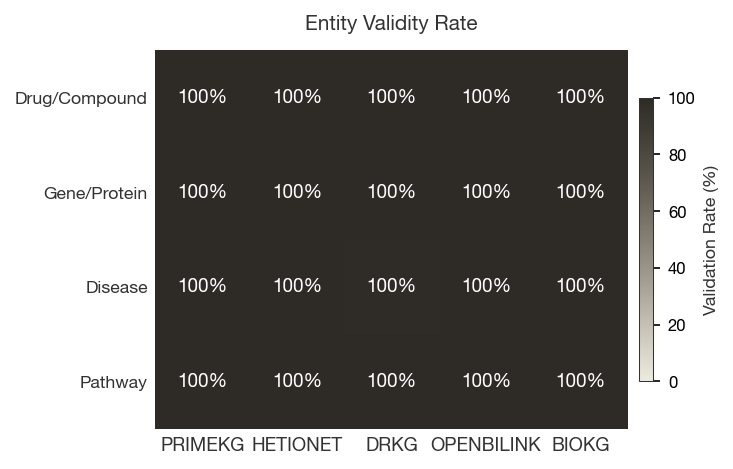

In [10]:
# Identifier validation rate heatmap - shared entity types only (present in all KGs)
ROW_ORDER = [
    'Drug/Compound', 'Gene/Protein', 'Disease',
    'Biological Process', 'Molecular Function', 'Cellular Component',
    'Anatomy', 'Phenotype (HP)', 'Pathway', 'Exposure',
]

val_df['Canonical Type'] = val_df['Entity Type'].map(_CANONICAL).fillna(val_df['Entity Type'])
pivot = val_df.pivot_table(index='Canonical Type', columns='KG', values='Rate (%)', aggfunc='mean')
pivot = pivot.reindex(columns=KG_NAMES)
pivot = pivot.reindex([r for r in ROW_ORDER if r in pivot.index])

# Restrict to shared types only (no N/A cells) — consistent with dimension score calculation
shared_rows = [r for r in pivot.index if pivot.loc[r].notna().all()]
pivot = pivot.reindex(shared_rows)

fig, ax = plt.subplots(figsize=(5.0, len(pivot) * 0.55 + 1.0))

data  = pivot.values.astype(float)
valid = ~np.isnan(data)
cmap  = HEATMAP_CMAP

im = ax.pcolormesh(np.where(valid, data, np.nan), cmap=cmap, vmin=0, vmax=100,
                   edgecolors='none', linewidth=0, antialiased=False)

ax.set_xticks([x + 0.5 for x in range(len(pivot.columns))])
ax.set_xticklabels([k.upper() for k in pivot.columns], fontsize=9, color=TEXT_COLOR)
ax.set_yticks([y + 0.5 for y in range(len(pivot.index))])
ax.set_yticklabels(pivot.index, fontsize=8.5, color=TEXT_COLOR)
ax.tick_params(length=0, which='both')
ax.grid(False, which='both')
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.iloc[i, j]
        if pd.notna(val):
            ax.text(j + 0.5, i + 0.5, f'{val:.0f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if val >= 55 else TEXT_COLOR)

cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Validation Rate (%)', fontsize=8.5, color=TEXT_COLOR)
ax.set_title('Entity Validity Rate', fontsize=10,
             fontweight='bold', color=TEXT_COLOR, pad=10)

plt.tight_layout()
save_fig(fig, FIGS, '02_id_validation')
plt.show()

In [11]:
# API spot-check
# Hits live endpoints; cached results are returned immediately on re-runs.

api_val_results = []
print(f'API spot-check - up to {N_API_SAMPLES} nodes per entity type\n')

for kg_name, val_nodes in ((k, kg_val_nodes[k]) for k in KG_NAMES if k in kgs):
    if kg_name not in KG_VALIDATORS:
        print(f'-- {kg_name}: no validators configured - skipped\n')
        continue
    print(f'-- {kg_name} --')
    for etype_key, (api, prefix, regex, func) in KG_VALIDATORS[kg_name].items():
        base_etype = etype_key.split(' (')[0]
        sample     = _sample(val_nodes[val_nodes['type'] == base_etype], prefix, regex, N_API_SAMPLES)
        if sample.empty:
            print(f'  -  {etype_key:28s} [no matching nodes]')
            continue
        t0    = time.time()
        valid = func(sample)
        rate  = 100 * valid / len(sample)
        print(f'  {"OK" if rate >= 95 else "X "} {etype_key:28s} '
              f'{valid:3d}/{len(sample):3d} ({rate:5.1f}%)  via {api}  [{time.time()-t0:.1f}s]')
        api_val_results.append({'KG': kg_name, 'Entity Type': etype_key, 'API': api,
                                 'n': len(sample), 'Valid': valid, 'Rate (%)': round(rate, 1)})
    print()

api_val_df = pd.DataFrame(api_val_results)
if not api_val_df.empty:
    print('Overall by KG:')
    for kg_name, sub in api_val_df.groupby('KG'):
        print(f'  {kg_name:12s}: {sub["Valid"].sum():,}/{sub["n"].sum():,}'
              f' = {100*sub["Valid"].sum()/sub["n"].sum():.1f}%')


API spot-check - up to 10 nodes per entity type

-- primekg --
  OK drug                          10/ 10 (100.0%)  via DrugBank  [1.5s]
  OK gene/protein                  10/ 10 (100.0%)  via NCBI  [0.5s]
  OK disease                       10/ 10 (100.0%)  via OLS4  [1.6s]
  OK biological_process            10/ 10 (100.0%)  via QuickGO  [1.5s]
  OK molecular_function            10/ 10 (100.0%)  via QuickGO  [1.6s]
  OK cellular_component            10/ 10 (100.0%)  via QuickGO  [1.5s]
  OK anatomy                       10/ 10 (100.0%)  via OLS4  [1.5s]
  OK effect/phenotype              10/ 10 (100.0%)  via OLS4  [1.6s]
  OK pathway                       10/ 10 (100.0%)  via Reactome  [1.5s]
  OK exposure                      10/ 10 (100.0%)  via PubChem  [1.5s]

-- hetionet --
  X  Compound                       9/ 10 ( 90.0%)  via DrugBank  [1.6s]
  OK Gene                          10/ 10 (100.0%)  via NCBI  [0.5s]
  OK Disease                       10/ 10 (100.0%)  via OLS4  [1.6s]


### Node index uniqueness

Each internal node index must map to exactly one entity — an operational requirement for any embedding or matrix-based downstream model. Any collision is a **data integrity failure** that would silently corrupt learned representations.

In [12]:
# Node index uniqueness check
uniqueness_rows = []
for kg_name, data in kgs.items():
    nodes_df = data['nodes']
    n_total  = len(nodes_df)
    n_unique = nodes_df['idx'].nunique()
    n_dup    = n_total - n_unique
    rate     = 100 * n_unique / n_total
    print(f'  {"OK" if rate == 100 else " X"} {kg_name:12s}: {n_unique:,} unique / {n_total:,} total  ({rate:.2f}%)'
          + (f'  [{n_dup:,} collisions]' if n_dup else ''))
    uniqueness_rows.append({'KG': kg_name, 'Total nodes': n_total,
                             'Unique indices': n_unique, 'Uniqueness (%)': round(rate, 2)})

pd.DataFrame(uniqueness_rows).set_index('KG')

  OK primekg     : 129,375 unique / 129,375 total  (100.00%)
  OK hetionet    : 47,031 unique / 47,031 total  (100.00%)
  OK drkg        : 97,238 unique / 97,238 total  (100.00%)
  OK openbilink  : 185,929 unique / 185,929 total  (100.00%)
  OK biokg       : 105,524 unique / 105,524 total  (100.00%)


,Total nodes,Unique indices,Uniqueness (%)
KG,,,
primekg,129375,129375,100.0
hetionet,47031,47031,100.0
drkg,97238,97238,100.0
openbilink,185929,185929,100.0
biokg,105524,105524,100.0


## 2. Relational Consistency

Relational consistency assesses whether edges are correctly typed and semantically coherent. Two complementary checks are performed:

1. **Schema conformance** — each edge's `(x_type, y_type)` pair must match the allowed type pairs for its relation. Violations indicate entity-type misassignment in the graph construction pipeline.

$$\text{Conformance Rate} = \frac{|\text{conforming edges}|}{|\text{total edges}|}$$

2. **Relation exclusivity** — semantically contradictory relations (e.g., a drug simultaneously *indicated* and *contraindicated* for the same disease) must not share entity pairs. Any overlap signals a curation inconsistency.

> **Note:** Only schema conformance enters the dimension score. Relation exclusivity is reported as a diagnostic: KGs that do not define semantically exclusive relation pairs (e.g. DRKG, which lacks indication/contraindication edges) would receive a vacuous perfect score on this sub-metric, rewarding schema design choices rather than curation quality. Schema conformance is universally applicable and is the sole scored sub-metric.

In [13]:
# Schema config - KG-specific declarations; loops below are fully generic

def drkg_expected_types(rel_name: str) -> Optional[set]:
    '''Auto-derive allowed (x_type, y_type) pairs from DRKG relation name.

    DRKG format: SOURCE::rel::XType:YType - type pair encoded in the last segment.
    Returns a set of allowed pairs (both directions), or None if format unrecognised.
    '''
    parts = rel_name.split('::')
    if len(parts) >= 3 and ':' in parts[-1]:
        x, y = parts[-1].split(':', 1)
        return {(x, y), (y, x)} if x != y else {(x, y)}
    return None

# KG_SCHEMAS: kg_name -> relation -> set of allowed (x_type, y_type) pairs.
#   None value -> use drkg_expected_types() to auto-derive from relation name.
#   Key absent -> KG skipped during conformance check with a warning.
PRIMEKG_SCHEMA = {
    'drug_protein':               {('drug','gene/protein'), ('gene/protein','drug')},
    'indication':                 {('drug','disease'), ('disease','drug')},
    'contraindication':           {('drug','disease'), ('disease','drug')},
    'off-label use':              {('drug','disease'), ('disease','drug')},
    'drug_drug':                  {('drug','drug')},
    'drug_effect':                {('drug','effect/phenotype'), ('effect/phenotype','drug')},
    'disease_protein':            {('disease','gene/protein'), ('gene/protein','disease')},
    'disease_phenotype_positive': {('disease','effect/phenotype'), ('effect/phenotype','disease')},
    'disease_phenotype_negative': {('disease','effect/phenotype'), ('effect/phenotype','disease')},
    'protein_protein':            {('gene/protein','gene/protein')},
    'bioprocess_protein':         {('biological_process','gene/protein'), ('gene/protein','biological_process')},
    'molfunc_protein':            {('molecular_function','gene/protein'), ('gene/protein','molecular_function')},
    'cellcomp_protein':           {('cellular_component','gene/protein'), ('gene/protein','cellular_component')},
    'exposure_protein':           {('exposure','gene/protein'), ('gene/protein','exposure')},
    'exposure_disease':           {('exposure','disease'), ('disease','exposure')},
    'exposure_bioprocess':        {('exposure','biological_process'), ('biological_process','exposure')},
    'exposure_molfunc':           {('exposure','molecular_function'), ('molecular_function','exposure')},
    'exposure_cellcomp':          {('exposure','cellular_component'), ('cellular_component','exposure')},
    'anatomy_protein_present':    {('anatomy','gene/protein'), ('gene/protein','anatomy')},
    'anatomy_protein_absent':     {('anatomy','gene/protein'), ('gene/protein','anatomy')},
    'disease_disease':            {('disease','disease')},
    'anatomy_anatomy':            {('anatomy','anatomy')},
    'pathway_protein':            {('pathway','gene/protein'), ('gene/protein','pathway')},
    'pathway_pathway':            {('pathway','pathway')},
    'phenotype_protein':          {('effect/phenotype','gene/protein'), ('gene/protein','effect/phenotype')},
    'phenotype_phenotype':        {('effect/phenotype','effect/phenotype')},
    'bioprocess_bioprocess':      {('biological_process','biological_process')},
    'molfunc_molfunc':            {('molecular_function','molecular_function')},
    'cellcomp_cellcomp':          {('cellular_component','cellular_component')},
    'exposure_exposure':          {('exposure','exposure')},
}

HETIONET_SCHEMA = {
    'CbG':  {('Compound','Gene'),               ('Gene','Compound')},
    'CcSE': {('Compound','Side Effect'),         ('Side Effect','Compound')},
    'CdG':  {('Compound','Gene'),               ('Gene','Compound')},
    'CpD':  {('Compound','Disease'),            ('Disease','Compound')},
    'CrC':  {('Compound','Compound')},
    'CtD':  {('Compound','Disease'),            ('Disease','Compound')},
    'CuG':  {('Compound','Gene'),               ('Gene','Compound')},
    'DaG':  {('Disease','Gene'),                ('Gene','Disease')},
    'DdG':  {('Disease','Gene'),                ('Gene','Disease')},
    'DlA':  {('Disease','Anatomy'),             ('Anatomy','Disease')},
    'DpS':  {('Disease','Symptom'),             ('Symptom','Disease')},
    'DrD':  {('Disease','Disease')},
    'DuG':  {('Disease','Gene'),                ('Gene','Disease')},
    'GcG':  {('Gene','Gene')},
    'GiG':  {('Gene','Gene')},
    'GpBP': {('Gene','Biological Process'),     ('Biological Process','Gene')},
    'GpCC': {('Gene','Cellular Component'),     ('Cellular Component','Gene')},
    'GpMF': {('Gene','Molecular Function'),     ('Molecular Function','Gene')},
    'GpPW': {('Gene','Pathway'),                ('Pathway','Gene')},
    'GrG':  {('Gene','Gene')},
    'Gr>G': {('Gene','Gene')},
    'PCiC': {('Pharmacologic Class','Compound'),('Compound','Pharmacologic Class')},
    'AeG':  {('Anatomy','Gene'),                ('Gene','Anatomy')},
    'AuG':  {('Anatomy','Gene'),                ('Gene','Anatomy')},
    'AdG':  {('Anatomy','Gene'),                ('Gene','Anatomy')},
}

# OpenBioLink schema: relation -> allowed (x_type, y_type) pairs.
# Type labels come from _PREFIX_TO_TYPE in load_openbilink():
#   Drug, Gene, Disease, Pathway, GO, Anatomy, Phenotype, Cell.
# Relations not listed here are skipped during conformance check (unknown relation types
# such as gene-gene interactions are omitted because they vary by STRING score tier).
OPENBILINK_SCHEMA = {
    # Drug-Gene interactions (various mechanism types from STITCH / curated sources)
    'GENE_DRUG':            {('Gene', 'Drug'), ('Drug', 'Gene')},
    'DRUG_BINDING_GENE':    {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_PREDBIND_GENE':   {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_BINDACT_GENE':    {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_BINDINH_GENE':    {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_INHIBITION_GENE': {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_ACTIVATION_GENE': {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_CATALYSIS_GENE':  {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_REACTION_GENE':   {('Drug', 'Gene'), ('Gene', 'Drug')},
    'DRUG_EXPRESSION_GENE': {('Drug', 'Gene'), ('Gene', 'Drug')},
    # Drug-Disease and Drug-Phenotype
    'DIS_DRUG':             {('Disease', 'Drug'), ('Drug', 'Disease')},
    'DRUG_PHENOTYPE':       {('Drug', 'Phenotype'), ('Phenotype', 'Drug')},
}

BIOKG_SCHEMA = {
    'PPI':                         {('Gene/Protein', 'Gene/Protein')},
    'DPI':                         {('Drug', 'Gene/Protein'), ('Gene/Protein', 'Drug')},
    'DRUG_TARGET':                 {('Drug', 'Gene/Protein'), ('Gene/Protein', 'Drug')},
    'DRUG_CARRIER':                {('Drug', 'Gene/Protein'), ('Gene/Protein', 'Drug')},
    'DRUG_ENZYME':                 {('Drug', 'Gene/Protein'), ('Gene/Protein', 'Drug')},
    'DRUG_TRANSPORTER':            {('Drug', 'Gene/Protein'), ('Gene/Protein', 'Drug')},
    'DDI':                         {('Drug', 'Drug')},
    'PROTEIN_DISEASE_ASSOCIATION': {('Gene/Protein', 'Disease'), ('Disease', 'Gene/Protein')},
    'DRUG_DISEASE_ASSOCIATION':    {('Drug', 'Disease'), ('Disease', 'Drug')},
    'PROTEIN_PATHWAY_ASSOCIATION': {('Gene/Protein', 'Pathway'), ('Pathway', 'Gene/Protein')},
    'DRUG_PATHWAY_ASSOCIATION':    {('Drug', 'Pathway'), ('Pathway', 'Drug')},
    'DISEASE_PATHWAY_ASSOCIATION': {('Disease', 'Pathway'), ('Pathway', 'Disease')},
    'MEMBER_OF_COMPLEX':           {('Gene/Protein', 'Complex'), ('Complex', 'Gene/Protein')},
    'MEMBER_OF_PATHWAY':           {('Complex', 'Pathway'), ('Pathway', 'Complex')},
    'MEMBER_OF_TOP_LEVEL_PATHWAY': {('Complex', 'Pathway'), ('Pathway', 'Complex')},
    'COMPLEX_IN_PATHWAY':          {('Complex', 'Pathway'), ('Pathway', 'Complex')},
    'COMPLEX_TOP_LEVEL_PATHWAY':   {('Complex', 'Pathway'), ('Pathway', 'Complex')},
    'HAS_PARENT_PATHWAY':          {('Pathway', 'Pathway')},
    'DISEASE_GENETIC_DISORDER':    {('Disease', 'GeneticDisorder'), ('GeneticDisorder', 'Disease')},
    'RELATED_GENETIC_DISORDER':    {('Gene/Protein', 'GeneticDisorder'), ('GeneticDisorder', 'Gene/Protein')},
    'DISEASE_SUPERGRP':            {('Disease', 'DiseaseCategory'), ('DiseaseCategory', 'Disease')},
    'DRUG_SIDEEFFECT_ASSOCIATION': {('Drug', 'SideEffect'), ('SideEffect', 'Drug')},
    'DRUG_INDICATION_ASSOCIATION': {('Drug', 'Disease'), ('Disease', 'Drug')},
    'DRUG_ATC_CODE':               {('Drug', 'ATC'), ('ATC', 'Drug')},
    'PROTEIN_EXPRESSED_IN':        {('Gene/Protein', 'Tissue'), ('Tissue', 'Gene/Protein')},
    'PART_OF_TISSUE':              {('Cell', 'Tissue'), ('Tissue', 'Cell')},
}

KG_SCHEMAS: Dict[str, Optional[dict]] = {
    'primekg':    PRIMEKG_SCHEMA,
    'hetionet':   HETIONET_SCHEMA,
    'drkg':       None,          # None -> auto-derive from relation name via drkg_expected_types
    'openbilink': OPENBILINK_SCHEMA,
    'biokg':      BIOKG_SCHEMA,
}

# EXCLUSIVE_PAIRS: kg_name -> list of (label, rel_a, rel_b) that must not share entity pairs
# OpenBioLink: activation vs. inhibition of the same drug-gene pair are functionally opposite
# and their co-occurrence signals a curation inconsistency.
EXCLUSIVE_PAIRS: Dict[str, list] = {
    'primekg': [
        ('Indication vs. Contraindication', 'indication',       'contraindication'),
        ('Indication vs. Off-label',        'indication',       'off-label use'),
        ('Contraindication vs. Off-label',  'contraindication', 'off-label use'),
    ],
    'hetionet': [
        ('Treats (CtD) vs. Palliates (CpD)',      'CtD', 'CpD'),
        ('Compound: Up- vs. Downregulates Gene',  'CuG', 'CdG'),
        ('Anatomy:  Up- vs. Downregulates Gene',  'AuG', 'AdG'),
        ('Disease:  Up- vs. Downregulates Gene',  'DuG', 'DdG'),
    ],
    # OpenBioLink: drug activation vs. inhibition of the same gene are opposite effects;
    # any shared pair is a genuine curation conflict (994 found in HQ-filtered data).
    'openbilink': [
        ('Activation vs. Inhibition (direct)',  'DRUG_ACTIVATION_GENE', 'DRUG_INHIBITION_GENE'),
        ('Bind-Activate vs. Bind-Inhibit',     'DRUG_BINDACT_GENE',    'DRUG_BINDINH_GENE'),
        ('Bind-Activate vs. Inhibition',       'DRUG_BINDACT_GENE',    'DRUG_INHIBITION_GENE'),
        ('Activation vs. Bind-Inhibit',        'DRUG_ACTIVATION_GENE', 'DRUG_BINDINH_GENE'),
    ],
}

In [14]:
# Schema conformance - fully generic; KG-specific declarations are in the block above
print('Schema Conformance\n')
all_conformance = []

for kg_name, data in kgs.items():
    if kg_name not in KG_SCHEMAS:
        print(f'  - {kg_name:12s}: no schema defined - skipped')
        continue
    kg_df  = data['kg']
    schema = KG_SCHEMAS[kg_name]
    total_checked, total_violations = 0, 0
    violations_found = []

    for rel in kg_df['relation'].unique():
        edges    = kg_df[kg_df['relation'] == rel]
        n        = len(edges)
        total_checked += n
        expected = schema.get(rel) if schema is not None else drkg_expected_types(rel)
        if expected is None:
            continue  # relation not in schema (DRKG names without encoded types)
        observed   = set(zip(edges['x_type'].astype(str), edges['y_type'].astype(str)))
        unexpected = observed - expected
        if unexpected:
            n_bad = sum(len(edges[(edges['x_type'] == x) & (edges['y_type'] == y)])
                        for x, y in unexpected)
            total_violations += n_bad
            violations_found.append(f'    {rel}: {n_bad:,} edges with unexpected types {unexpected}')

    conformance = 100 * (1 - total_violations / total_checked) if total_checked else 100.0
    print(f'  {"OK" if conformance == 100 else " X"} {kg_name:12s}: {conformance:.2f}%  '
          f'({total_checked - total_violations:,}/{total_checked:,} edges conform)')
    for v in violations_found:
        print(v)
    all_conformance.append({'KG': kg_name, 'Total edges': total_checked,
                             'Violations': total_violations,
                             'Conformance (%)': round(conformance, 2)})

print()
pd.DataFrame(all_conformance).set_index('KG')

Schema Conformance

  OK primekg     : 100.00%  (8,100,498/8,100,498 edges conform)
  OK hetionet    : 100.00%  (2,250,197/2,250,197 edges conform)
  OK drkg        : 100.00%  (5,874,261/5,874,261 edges conform)
  OK openbilink  : 100.00%  (4,986,521/4,986,521 edges conform)
  OK biokg       : 100.00%  (2,067,998/2,067,998 edges conform)



,Total edges,Violations,Conformance (%)
KG,,,
primekg,8100498,0,100.0
hetionet,2250197,0,100.0
drkg,5874261,0,100.0
openbilink,4986521,0,100.0
biokg,2067998,0,100.0


### Relation exclusivity

Semantically exclusive relation pairs (e.g., *indication* vs. *contraindication*) must not be simultaneously assigned to the same entity pair. Any overlap signals a curation inconsistency that could introduce contradictory training signal in downstream link prediction models.

Exclusive pairs are defined per KG in `EXCLUSIVE_PAIRS`. KGs without applicable exclusive pairs (e.g., DRKG, which does not encode indication/contraindication semantics) are reported as N/A — this is expected, not a failure.

In [15]:
# Relation exclusivity - fully generic
def _edge_pairs(kg_df: pd.DataFrame, rel: str) -> set:
    '''Unordered bare-ID pairs for a relation (strips Type:: prefix).'''
    e = kg_df[kg_df['relation'] == rel]
    if e.empty:
        return set()
    strip = lambda s: s.split('::', 1)[1] if '::' in s else s
    x, y  = e['x_id'].astype(str).map(strip), e['y_id'].astype(str).map(strip)
    return {(a, b) if a <= b else (b, a) for a, b in zip(x, y)}

print('Relation Exclusivity\n')
excl_rows = []
for kg_name in LOADED:
    if kg_name not in EXCLUSIVE_PAIRS:
        print(f'  - {kg_name:12s}: no exclusive pairs defined\n')
        continue
    kg_df = kgs[kg_name]['kg']
    for label, rel_a, rel_b in EXCLUSIVE_PAIRS[kg_name]:
        A, B    = _edge_pairs(kg_df, rel_a), _edge_pairs(kg_df, rel_b)
        overlap = A & B
        rate    = 100 * len(overlap) / len(A | B) if (A | B) else 0.0
        print(f'  {"OK" if rate == 0 else " !"} [{kg_name}] {label:42s}  {len(overlap):,} conflicts  ({rate:.3f}%)')
        excl_rows.append({'KG': kg_name, 'Relation Pair': label,
                          '|A|': len(A), '|B|': len(B),
                          'Overlap': len(overlap), 'Conflict Rate (%)': round(rate, 3)})
    print()

pd.DataFrame(excl_rows).set_index(['KG', 'Relation Pair'])

Relation Exclusivity

   ! [primekg] Indication vs. Contraindication             87 conflicts  (0.218%)
   ! [primekg] Indication vs. Off-label                    125 conflicts  (1.057%)
   ! [primekg] Contraindication vs. Off-label              37 conflicts  (0.111%)

  OK [hetionet] Treats (CtD) vs. Palliates (CpD)            0 conflicts  (0.000%)
  OK [hetionet] Compound: Up- vs. Downregulates Gene        0 conflicts  (0.000%)
  OK [hetionet] Anatomy:  Up- vs. Downregulates Gene        0 conflicts  (0.000%)
  OK [hetionet] Disease:  Up- vs. Downregulates Gene        0 conflicts  (0.000%)

  - drkg        : no exclusive pairs defined

   ! [openbilink] Activation vs. Inhibition (direct)          994 conflicts  (2.907%)
   ! [openbilink] Bind-Activate vs. Bind-Inhibit              26 conflicts  (0.790%)
   ! [openbilink] Bind-Activate vs. Inhibition                42 conflicts  (0.205%)
   ! [openbilink] Activation vs. Bind-Inhibit                 86 conflicts  (0.480%)

  - biokg    

|A|     |B|  Overlap  \
KG         Relation Pair                                                  
primekg    Indication vs. Contraindication        9388   30675       87   
           Indication vs. Off-label               9388    2568      125   
           Contraindication vs. Off-label        30675    2568       37   
hetionet   Treats (CtD) vs. Palliates (CpD)        755     390        0   
           Compound: Up- vs. Downregulates Gene  18756   21102        0   
           Anatomy:  Up- vs. Downregulates Gene  97848  102240        0   
           Disease:  Up- vs. Downregulates Gene   7731    7623        0   
openbilink Activation vs. Inhibition (direct)    15954   19233      994   
           Bind-Activate vs. Bind-Inhibit         1259    2060       26   
           Bind-Activate vs. Inhibition           1259   19233       42   
           Activation vs. Bind-Inhibit           15954    2060       86   

                                                 Conflict Rate (%)  
KG         Relation Pair                                            
primekg    Indication vs. Contraindication                   0.218  
           Indication vs. Off-label                          1.057  
           Contraindication vs. Off-label                    0.111  
hetionet   Treats (CtD) vs. Palliates (CpD)                  0.000  
           Compound: Up- vs. Downregulates Gene              0.000  
           Anatomy:  Up- vs. Downregulates Gene              0.000  
           Disease:  Up- vs. Downregulates Gene              0.000  
openbilink Activation vs. Inhibition (direct)                2.907  
           Bind-Activate vs. Bind-Inhibit                    0.790  
           Bind-Activate vs. Inhibition                      0.205  
           Activation vs. Bind-Inhibit                       0.480

### Diagnostic: Relation Exclusivity Conflicts

For KGs with detected conflicts, the table below lists the actual overlapping entity pairs. This allows curators to inspect whether the conflict reflects a genuine data error (e.g., a drug–disease pair labelled as both *indication* and *contraindication*) or an edge case that is clinically valid (e.g., dose-dependent or population-dependent indication/contraindication).

In [16]:
# List actual conflicting entity pairs for each exclusive relation pair
# Resolves raw IDs to human-readable entity names so developers can trace
# each conflict back to the original data.
N_CONFLICT_EXAMPLES = 20  # max conflicts to display per pair

# Build per-KG ID → name lookup from node tables
_id_to_name = {}
for kg_name in LOADED:
    nodes = kgs[kg_name]['nodes']
    strip = lambda s: s.split('::', 1)[1] if '::' in str(s) else str(s)
    _id_to_name[kg_name] = {
        strip(row['id']): str(row['name'])
        for _, row in nodes.iterrows()
        if pd.notna(row.get('name'))
    }

conflict_detail_rows = []
print('Relation exclusivity conflict details\n')

for kg_name in LOADED:
    if kg_name not in EXCLUSIVE_PAIRS:
        continue
    kg_df   = kgs[kg_name]['kg']
    id2name = _id_to_name.get(kg_name, {})
    for label, rel_a, rel_b in EXCLUSIVE_PAIRS[kg_name]:
        A       = _edge_pairs(kg_df, rel_a)
        B       = _edge_pairs(kg_df, rel_b)
        overlap = sorted(A & B)
        if not overlap:
            continue

        print(f'  [{kg_name}] {label}  — {len(overlap)} conflicts:')
        print(f'  {"Entity A ID":>22s}  {"Entity A Name":>30s}  ↔  {"Entity B ID":<22s}  {"Entity B Name":<30s}')
        print(f'  ' + '-' * 112)
        for pair in overlap[:N_CONFLICT_EXAMPLES]:
            name_a = id2name.get(pair[0], '?')
            name_b = id2name.get(pair[1], '?')
            print(f'  {pair[0]:>22s}  {name_a:>30s}  ↔  {pair[1]:<22s}  {name_b:<30s}')
            conflict_detail_rows.append({
                'KG': kg_name, 'Conflict': label,
                'Entity_A_ID': pair[0], 'Entity_A_Name': name_a,
                'Entity_B_ID': pair[1], 'Entity_B_Name': name_b,
            })
        if len(overlap) > N_CONFLICT_EXAMPLES:
            print(f'    ... and {len(overlap) - N_CONFLICT_EXAMPLES} more')

        # Show the actual edge records for the first few conflicts
        # so developers can inspect source columns and relation metadata
        print(f'\n  Example edge records for first 3 conflicts:')
        for pair in overlap[:3]:
            mask = (
                ((kg_df['x_id'].astype(str).str.endswith(pair[0])) &
                 (kg_df['y_id'].astype(str).str.endswith(pair[1]))) |
                ((kg_df['x_id'].astype(str).str.endswith(pair[1])) &
                 (kg_df['y_id'].astype(str).str.endswith(pair[0])))
            )
            hits = kg_df[mask & kg_df['relation'].isin([rel_a, rel_b])]
            if not hits.empty:
                cols = [c for c in ['relation', 'x_id', 'x_name', 'y_id', 'y_name',
                                     'x_source', 'y_source'] if c in hits.columns]
                display(hits[cols].head(4))
        print()

if not conflict_detail_rows:
    print('  No relation exclusivity conflicts detected.')
else:
    conflict_df = pd.DataFrame(conflict_detail_rows)
    _conflict_path = BASE / 'results' / 'relation_conflicts.csv'
    conflict_df.to_csv(_conflict_path, index=False)
    print(f'  → Exported all conflicts to {_conflict_path.name}')
    print(f'    ({len(conflict_df)} conflict pairs across all KGs)')

Relation exclusivity conflict details

  [primekg] Indication vs. Contraindication  — 87 conflicts:
             Entity A ID                   Entity A Name  ↔  Entity B ID             Entity B Name                 
  ----------------------------------------------------------------------------------------------------------------
  10162_10160_10161_4741                     tyrosinemia  ↔  DB00348                 Nitisinone                    
  1200_1134_15512_5080_100078                    hypertension  ↔  DB00622                 Nicardipine                   
                    1517  N-acetylglucosamine 6-O-sulfotransferase activity  ↔  DB00836                 Loperamide                    
                    1566  non-kinase phorbol ester receptor activity  ↔  DB00136                 Calcitriol                    
                    1566  non-kinase phorbol ester receptor activity  ↔  DB00146                 Calcifediol                   
                    1566  non-kinase phor

,relation,x_id,x_name,y_id,y_name,x_source,y_source
389348,contraindication,DB00348,Nitisinone,10162_10160_10161_4741,tyrosinemia,DrugBank,MONDO_grouped
389349,indication,DB00348,Nitisinone,10162_10160_10161_4741,tyrosinemia,DrugBank,MONDO_grouped
5776148,contraindication,10162_10160_10161_4741,tyrosinemia,DB00348,Nitisinone,MONDO_grouped,DrugBank
5776149,indication,10162_10160_10161_4741,tyrosinemia,DB00348,Nitisinone,MONDO_grouped,DrugBank


,relation,x_id,x_name,y_id,y_name,x_source,y_source
347055,indication,DB00622,Nicardipine,1200_1134_15512_5080_100078,hypertension,DrugBank,MONDO_grouped
387213,contraindication,DB00622,Nicardipine,1200_1134_15512_5080_100078,hypertension,DrugBank,MONDO_grouped
5733855,indication,1200_1134_15512_5080_100078,hypertension,DB00622,Nicardipine,MONDO_grouped,DrugBank
5774013,contraindication,1200_1134_15512_5080_100078,hypertension,DB00622,Nicardipine,MONDO_grouped,DrugBank


,relation,x_id,x_name,y_id,y_name,x_source,y_source
380989,contraindication,DB00836,Loperamide,1517,dysentery,DrugBank,MONDO
383301,indication,DB00836,Loperamide,1517,dysentery,DrugBank,MONDO
5767789,contraindication,1517,dysentery,DB00836,Loperamide,MONDO,DrugBank
5770101,indication,1517,dysentery,DB00836,Loperamide,MONDO,DrugBank



  [primekg] Indication vs. Off-label  — 125 conflicts:
             Entity A ID                   Entity A Name  ↔  Entity B ID             Entity B Name                 
  ----------------------------------------------------------------------------------------------------------------
                    1068  transcription regulatory region RNA binding  ↔  DB00146                 Calcifediol                   
         10917_7319_1314               chondrocalcinosis  ↔  DB00443                 Betamethasone                 
         10917_7319_1314               chondrocalcinosis  ↔  DB00620                 Triamcinolone                 
         10917_7319_1314               chondrocalcinosis  ↔  DB00635                 Prednisone                    
         10917_7319_1314               chondrocalcinosis  ↔  DB00860                 Prednisolone                  
         10917_7319_1314               chondrocalcinosis  ↔  DB00959                 Methylprednisolone            
    

...


  [openbilink] Activation vs. Bind-Inhibit  — 86 conflicts:
             Entity A ID                   Entity A Name  ↔  Entity B ID             Entity B Name                 
  ----------------------------------------------------------------------------------------------------------------
          NCBIGENE:11255                           11255  ↔  PUBCHEM.COMPOUND:156615  156615                        
           NCBIGENE:1128                            1128  ↔  PUBCHEM.COMPOUND:4168   4168                          
           NCBIGENE:1128                            1128  ↔  PUBCHEM.COMPOUND:5314   5314                          
            NCBIGENE:146                             146  ↔  PUBCHEM.COMPOUND:31100  31100                         
            NCBIGENE:146                             146  ↔  PUBCHEM.COMPOUND:47811  47811                         
            NCBIGENE:147                             147  ↔  PUBCHEM.COMPOUND:31100  31100                         
           

,relation,x_id,x_name,y_id,y_name,x_source,y_source
154495,DRUG_ACTIVATION_GENE,PUBCHEM.COMPOUND:156615,156615,NCBIGENE:11255,11255,STITCH,STITCH
154499,DRUG_BINDINH_GENE,PUBCHEM.COMPOUND:156615,156615,NCBIGENE:11255,11255,STITCH,STITCH


,relation,x_id,x_name,y_id,y_name,x_source,y_source
246304,DRUG_ACTIVATION_GENE,PUBCHEM.COMPOUND:4168,4168,NCBIGENE:1128,1128,STITCH,STITCH
246450,DRUG_BINDINH_GENE,PUBCHEM.COMPOUND:4168,4168,NCBIGENE:1128,1128,STITCH,STITCH


,relation,x_id,x_name,y_id,y_name,x_source,y_source
331681,DRUG_ACTIVATION_GENE,PUBCHEM.COMPOUND:5314,5314,NCBIGENE:1128,1128,STITCH,STITCH
331693,DRUG_BINDINH_GENE,PUBCHEM.COMPOUND:5314,5314,NCBIGENE:1128,1128,STITCH,STITCH



  → Exported all conflicts to relation_conflicts.csv
    (140 conflict pairs across all KGs)


In [17]:
# Checkpoint
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# ── 1. Shared entity types (intersection across all KGs) ──────────────
#   Fair comparison: only score types present in every KG.
val_df['Canonical Type'] = val_df['Entity Type'].map(_CANONICAL).fillna(val_df['Entity Type'])
per_kg_types = {
    kg: set(sub['Canonical Type'].dropna().unique())
    for kg, sub in val_df.groupby('KG')
}
SHARED_CANON_TYPES = sorted(set.intersection(*per_kg_types.values()))
print(f'Shared entity types ({len(SHARED_CANON_TYPES)}): {SHARED_CANON_TYPES}')

# ── 2. Entity validity — equal-weighted mean across shared types ──────
#   Per-type rate (not node-count weighted) avoids bias from KGs with
#   many more nodes of a given type.
entity_validity = {}
for kg_name, sub in val_df.groupby('KG'):
    type_rates = []
    for ctype in SHARED_CANON_TYPES:
        rows = sub[sub['Canonical Type'] == ctype]
        if rows.empty:
            continue
        rate = rows['Valid'].sum() / rows['n'].sum()
        type_rates.append(rate)
    entity_validity[kg_name] = round(np.mean(type_rates), 4) if type_rates else 0.0
    print(f'  {kg_name:12s}: entity validity = {entity_validity[kg_name]:.4f}  '
          f'({len(type_rates)} shared types)')

# ── 3. Relational consistency — schema conformance rate ───────────────
#   All KGs have schema definitions; conformance % is fair across all.
relational_consistency = {}
for row in all_conformance:
    kg = row['KG']
    relational_consistency[kg] = round(row['Conformance (%)'] / 100.0, 4)
    print(f'  {kg:12s}: relational consistency = {relational_consistency[kg]:.4f}')

# ── 4. Summary = equal-weighted mean of 2 sub-scores ─────────────────
summary_scores = {}
sub_scores = {}
for kg_name in KG_NAMES:
    ev = entity_validity.get(kg_name, 0.0)
    rc = relational_consistency.get(kg_name, 0.0)
    summary_scores[kg_name] = round((ev + rc) / 2.0, 4)
    sub_scores[kg_name] = {
        'entity_validity':        ev,
        'relational_consistency': rc,
    }

print(f'\nAnnotation accuracy (shared-types, 2 sub-metrics):')
for kg_name in KG_NAMES:
    ss = sub_scores[kg_name]
    print(f'  {kg_name:12s}: {summary_scores[kg_name]:.4f}  '
          f'(entity={ss["entity_validity"]:.4f}, relational={ss["relational_consistency"]:.4f})')

# ── 5. Save checkpoint ───────────────────────────────────────────────
ckpt = {
    'summary_scores': summary_scores,
    'sub_scores':     sub_scores,
    'shared_types':   SHARED_CANON_TYPES,
    'val_records':    val_df.to_dict('records') if not val_df.empty else [],
    'conformance':    all_conformance,
}
out = CKPT_DIR / '02_semantic_validity.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)
print(f'\nCheckpoint saved: {out}')

Shared entity types (4): ['Disease', 'Drug/Compound', 'Gene/Protein', 'Pathway']
  biokg       : entity validity = 1.0000  (4 shared types)
  drkg        : entity validity = 0.9983  (4 shared types)
  hetionet    : entity validity = 1.0000  (4 shared types)
  openbilink  : entity validity = 1.0000  (4 shared types)
  primekg     : entity validity = 1.0000  (4 shared types)
  primekg     : relational consistency = 1.0000
  hetionet    : relational consistency = 1.0000
  drkg        : relational consistency = 1.0000
  openbilink  : relational consistency = 1.0000
  biokg       : relational consistency = 1.0000

Annotation accuracy (shared-types, 2 sub-metrics):
  primekg     : 1.0000  (entity=1.0000, relational=1.0000)
  hetionet    : 1.0000  (entity=1.0000, relational=1.0000)
  drkg        : 0.9992  (entity=0.9983, relational=1.0000)
  openbilink  : 1.0000  (entity=1.0000, relational=1.0000)
  biokg       : 1.0000  (entity=1.0000, relational=1.0000)

Checkpoint saved: /Users/shil6661/bi

## Dimension Score

The annotation accuracy dimension score combines the two sub-metrics:

$$\text{Annotation Accuracy} = \frac{1}{2}\left(\text{Entity Validity} + \text{Relational Consistency}\right)$$

**Entity validity** is computed as the equal-weighted mean of per-type validation rates across **shared entity types only** (types present in all KGs). This avoids bias from KGs that define more entity types. **Relational consistency** uses the schema conformance rate, which is available for all KGs.